# Prototype 2 — Baseline Comparison

Prototype 1 identified 60 single-day decline events of 8% or greater across a ten-stock large-cap US equity sample between 2016 and 2025. Of these events, 58.3% subsequently reached a closing price at least 5% above the event-day close within the following ten trading days.

How can we tell whether this 5% increase in the 10-day forward return is good, bad, or normal?
 
There is no baseline to compare it to! 

Prototype 2 introduces this baseline.

**Hypothesis 2**: US large-cap stocks that fall by at least 8% in one trading day are more likely to subsequently rise by at least 5% within ten trading days than they are after an ordinary trading day.

### Parameters:

- **Event**: Daily close-to-close return ≤ -8%
- **Control Day**: Any trading day where the daily return is > -8%
- **Universe**: The same ten large-cap US equities used in Prototype 1:
    - AAPL
    - MSFT
    - AMZN
    - GOOGL
    - META
    - JPM
    - JNJ
    - XOM
    - WMT
    - NVDA
- **Historical Period**: 01 January 2016 to 01 January 2026
- **Outcome**: Whether the stock rises at least 5% from the starting day's adjusted closing price within the following 10 trading days
- **Control Matching**: Each simulated control sample contains the same number of observations for each stock as the event sample
- **Number of Simulations**: 1,000 randomly sampled control groups
- **Primary Metric**: Difference between the event recovery hit rate and the average control recovery hit rate
- **Secondary Metrics**:
    - Distribution of simulated control hit rates
    - Percentage of control simulations that equal or exceed the observed event hit rate

## Import Libraries

In [1]:
# If yfinance is not installed, uncomment the next line:
# !pip install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Recreate the Prototype Dataset

The same stock universe, historical period and Yahoo! Finance data source used in Prototype 1 are retained so that the baseline comparison is made against the original experiment under the same conditions.

In [2]:
# Same ten large-cap US equities used in Prototype 1
tickers = [
    "AAPL", "MSFT", "AMZN", "GOOGL", "META",
    "JPM", "JNJ", "XOM", "WMT", "NVDA"
]

# Same ten-year historical period
start_date = "2016-01-01"
end_date = "2026-01-01"

# Download historical stock data from Yahoo! Finance
prices = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=True
)

prices.head()

[*********************100%***********************]  10 of 10 completed


Price       Adj Close                                                          \
Ticker           AAPL       AMZN      GOOGL        JNJ        JPM        META   
Date                                                                            
2016-01-04  23.688673  31.849501  37.638252  74.967796  48.184067  101.330162   
2016-01-05  23.095055  31.689501  37.741837  75.281174  48.267376  101.835724   
2016-01-06  22.643084  31.632500  37.632805  74.900673  47.570595  102.073631   
2016-01-07  21.687449  30.396999  36.724358  74.027725  45.646870   97.067581   
2016-01-08  21.802118  30.352501  36.224297  73.236862  44.624420   96.482735   

Price                                                  ...     Volume  \
Ticker           MSFT      NVDA        WMT        XOM  ...       AAPL   
Date                                                   ...              
2016-01-04  47.680969  0.788626  16.966860  49.002312  ...  270597600   
2016-01-05  47.898483  0.801295  17.369905  49.419849  ...  223164000   
2016-01-06  47.028393  0.768161  17.543827  49.008640  ...  273829600   
2016-01-07  45.392609  0.737707  17.952398  48.224201  ...  324377600   
2016-01-08  45.531837  0.721872  17.541067  47.249977  ...  283192000   

Price                                                                    \
Ticker           AMZN     GOOGL       JNJ       JPM      META      MSFT   
Date                                                                      
2016-01-04  186290000  67382000  12722800  25393200  37912400  53778000   
2016-01-05  116452000  45216000   6467200  16566700  23258200  34079700   
2016-01-06  106584000  48206000   7733800  22961500  25096200  39518900   
2016-01-07  141498000  63132000   9433100  27630900  45172900  56564900   
2016-01-08  110258000  47506000   9766700  22373300  35402300  48754000   

Price                                      
Ticker           NVDA       WMT       XOM  
Date                                       
2016-01-04  358076000  35967600  20400100  
2016-01-05  490272000  39978000  11993500  
2016-01-06  449344000  49693800  18826900  
2016-01-07  645304000  79290000  21263800  
2016-01-08  398472000  53303700  19033600  

[5 rows x 60 columns]

As in Prototype 1, adjusted closing prices are used to reduce distortions caused by corporate actions such as stock splits and dividends.

Daily close-to-close percentage returns are then calculated from the adjusted closing prices.

In [3]:
# Extract adjusted closing prices
adj_close = prices["Adj Close"].copy()

adj_close.head()

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NVDA,WMT,XOM
Date,,,,,,,,,,
2016-01-04,23.688673,31.849501,37.638252,74.967796,48.184067,101.330162,47.680969,0.788626,16.966860,49.002312
2016-01-05,23.095055,31.689501,37.741837,75.281174,48.267376,101.835724,47.898483,0.801295,17.369905,49.419849
2016-01-06,22.643084,31.632500,37.632805,74.900673,47.570595,102.073631,47.028393,0.768161,17.543827,49.008640
2016-01-07,21.687449,30.396999,36.724358,74.027725,45.646870,97.067581,45.392609,0.737707,17.952398,48.224201
2016-01-08,21.802118,30.352501,36.224297,73.236862,44.624420,96.482735,45.531837,0.721872,17.541067,47.249977


In [4]:
# Calculate the percentage change from the previous trading day's adjusted close
daily_returns = adj_close.pct_change()

daily_returns.head()

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NVDA,WMT,XOM
Date,,,,,,,,,,
2016-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-05,-0.025059,-0.005024,0.002752,0.004180,0.001729,0.004989,0.004562,0.016064,0.023755,0.008521
2016-01-06,-0.019570,-0.001799,-0.002889,-0.005054,-0.014436,0.002336,-0.018165,-0.041350,0.010013,-0.008321
2016-01-07,-0.042204,-0.039058,-0.024140,-0.011655,-0.040439,-0.049044,-0.034783,-0.039645,0.023289,-0.016006
2016-01-08,0.005287,-0.001464,-0.013617,-0.010683,-0.022399,-0.006025,0.003067,-0.021466,-0.022912,-0.020202


## Recreate the Large-Drop Event Sample

Prototype 1 defined a qualifying event as a daily return of -8% or lower.

The same rule is reproduced here so that the observed event hit rate can be compared directly with the new control samples.

In [5]:
# Define a large single-day decline
drop_threshold = -0.08

# Convert the daily return table from wide format to long format
events = (
    daily_returns
    .stack()
    .reset_index()
)

# Give the columns standard names
events.columns = ["Date", "Ticker", "Daily_Return"]

# Keep only observations where the stock fell by at least 8%
events = events[
    events["Daily_Return"] <= drop_threshold
].copy()

# Sort chronologically
events = events.sort_values("Date").reset_index(drop=True)

events.head(10)

,Date,Ticker,Daily_Return
0,2017-02-23,NVDA,-0.092723
1,2018-02-05,NVDA,-0.084875
2,2018-02-20,WMT,-0.101833
3,2018-07-26,META,-0.189609
4,2018-10-24,NVDA,-0.097937
5,2018-11-16,NVDA,-0.187559
6,2018-11-19,NVDA,-0.119990
7,2018-12-14,JNJ,-0.100379
8,2019-01-03,AAPL,-0.099607
9,2019-01-28,NVDA,-0.138246


In [6]:
# Count qualifying large-drop events for each stock

event_counts = (
    events["Ticker"]
    .value_counts()
    .reindex(tickers)
    .fillna(0)
    .astype(int)
)

event_counts

Ticker
AAPL      5
MSFT      2
AMZN      5
GOOGL     4
META     10
JPM       5
JNJ       1
XOM       5
WMT       4
NVDA     19
Name: count, dtype: int64

## Define the Forward Recovery Outcome

The outcome definition remains unchanged from Prototype 1.

For every starting observation:

1. Record the adjusted closing price on the starting date.
2. Examine the following ten trading days.
3. Identify the maximum adjusted closing price reached during that period.
4. Calculate the maximum percentage increase from the starting price.
5. Record whether the increase reached or exceeded 5%.

The same calculation will be applied to both large-drop events and ordinary control days.

In [7]:
# Add the adjusted closing price on each large-drop event date

events["Start_Price"] = events.apply(
    lambda row: adj_close.loc[row["Date"], row["Ticker"]],
    axis=1
)

events.head()

,Date,Ticker,Daily_Return,Start_Price
0,2017-02-23,NVDA,-0.092723,2.474879
1,2018-02-05,NVDA,-0.084875,5.276873
2,2018-02-20,WMT,-0.101833,27.425871
3,2018-07-26,META,-0.189609,174.725616
4,2018-10-24,NVDA,-0.097937,4.932815


In [8]:
# Define the recovery rule used for both event days and control days

def check_forward_recovery(row, recovery_threshold=0.05, forward_days=10):
    
    # Identify the stock and starting date
    ticker = row["Ticker"]
    start_date = row["Date"]
    start_price = row["Start_Price"]

    # Find the integer position of the starting date in the price dataset
    start_index = adj_close.index.get_loc(start_date)

    # Select the following ten trading days
    future_prices = adj_close[ticker].iloc[
        start_index + 1 : start_index + 1 + forward_days
    ]

    # If there are no future observations available, return missing values
    if len(future_prices) == 0:
        return pd.Series([np.nan, np.nan])

    # Find the highest adjusted closing price reached during the forward window
    max_future_price = future_prices.max()

    # Calculate the maximum percentage increase from the starting price
    max_recovery = (
        max_future_price - start_price
    ) / start_price

    # Determine whether the 5% recovery threshold was reached
    recovered = max_recovery >= recovery_threshold

    return pd.Series([max_recovery, recovered])

In [9]:
# Apply the forward recovery calculation to every large-drop event
# Max_Recovery_10D --> maximum +% change in 10 days 
# Recovered_5pct_10D --> True/False value 
events[
    ["Max_Recovery_10D", "Recovered_5pct_10D"]
] = events.apply(
    check_forward_recovery,
    axis=1
)

events.head(10)

,Date,Ticker,Daily_Return,Start_Price,Max_Recovery_10D,Recovered_5pct_10D
0,2017-02-23,NVDA,-0.092723,2.474879,0.039009,False
1,2018-02-05,NVDA,-0.084875,5.276873,0.165559,True
2,2018-02-20,WMT,-0.101833,27.425871,-0.010519,False
3,2018-07-26,META,-0.189609,174.725616,0.053501,True
4,2018-10-24,NVDA,-0.097937,4.932815,0.093777,True
5,2018-11-16,NVDA,-0.187559,4.067513,0.035152,False
6,2018-11-19,NVDA,-0.119990,3.579450,0.176297,True
7,2018-12-14,JNJ,-0.100379,107.526054,-0.019399,False
8,2019-01-03,AAPL,-0.099607,33.707928,0.096139,True
9,2019-01-28,NVDA,-0.138246,3.417375,0.108616,True


## Confirm the Prototype 1 Result

Before constructing the baseline, the original event result is recalculated.

This acts as a simple reproducibility check and provides the observed hit rate that the simulated control groups will be compared against.

In [10]:
# Remove observations where a forward recovery outcome could not be calculated
valid_events = events.dropna(
    subset=["Recovered_5pct_10D"]
).copy()

# Calculate the recovery hit rate across large-drop events
event_hit_rate = valid_events[
    "Recovered_5pct_10D"
].mean()

print(f"Number of large-drop events: {len(valid_events)}")
print(f"Large-drop recovery hit rate: {event_hit_rate:.1%}")

Number of large-drop events: 60
Large-drop recovery hit rate: 58.3%


## Construct an Ordinary-Day Control Group

A **baseline** is required to determine whether the 58.3% event recovery rate is unusual.

**Control observations** are therefore sampled from trading days that **did not meet** the large-drop condition.

To prevent differences in stock composition from affecting the comparison, _the control sample is matched to the event sample by ticker_.

For example, if NVDA contributes 19 large-drop events to the event sample, each control sample will also contain 19 randomly selected NVDA control days.

Only dates with ten subsequent trading days available are eligible for sampling.

In [11]:
# Number of future trading days required by the recovery rule
forward_days = 10

# Dictionary that will store the eligible control dates for each stock
eligible_control_dates = {}

#for each stock:
for ticker in tickers:

    # Take the daily returns for one stock and remove missing observations
    ticker_returns = daily_returns[ticker].dropna()

    # Ordinary/control days are days that did NOT experience an 8% or greater decline
    ticker_control_dates = ticker_returns[
        ticker_returns > drop_threshold
    ].index

    # Keep only dates where ten future trading days exist in the dataset
    #list comprehension is basically a compact for loop! 
    #ticker_control_dates is a new list defined, where: 
    ticker_control_dates = [
        date #thing we want to keep
        for date in ticker_control_dates #for thing in collection 
        #len(adj_close.index) --> length of the list of adjusted closing prices
        if adj_close.index.get_loc(date) + forward_days < len(adj_close.index) #if condition met --> date has 10 future trading days worth of data 
    ]

    # Store the eligible dates for this ticker
    eligible_control_dates[ticker] = ticker_control_dates

In [22]:
# Check how many ordinary control dates are available for each stock

#conceptually eligible_control_dates looks like this
#eligible_control_dates = {
#    "AAPL": [date1, date2, date3, ...],
#    "MSFT": [date1, date2, date3, ...],
#    "AMZN": [date1, date2, date3, ...],
#    ...
#}
#this is a dictionary comprehension
#For every ticker and its list of eligible dates, store the ticker as the key and the number of eligible dates as the value.
eligible_control_counts = pd.Series(
    {
        #key: value
        ticker: len(dates) 
        for ticker, dates in eligible_control_dates.items()
    }
)

#print the dictionary 
eligible_control_counts

AAPL     2498
MSFT     2501
AMZN     2498
GOOGL    2499
META     2493
JPM      2498
JNJ      2502
XOM      2498
WMT      2499
NVDA     2484
dtype: int64

### Sample One Matched Control Group

Before running repeated simulations, one control sample is generated and inspected.

A fixed random seed is used so that this particular sample can be reproduced.

For every stock, the number of randomly selected control dates is equal to the number of large-drop events observed for that stock.

In [13]:
# Create a reproducible random number generator, seed is 42
rng = np.random.default_rng(42)

# Empty list that will hold the sampled control observations
control_rows = []

for ticker in tickers:

    # Number of large-drop events observed for this stock
    number_of_events = event_counts[ticker]

    # Randomly select the same number of ordinary trading days
    sampled_dates = rng.choice(
        eligible_control_dates[ticker],
        size=number_of_events,
        replace=False
    )

    # Create one row for every selected control date
    for date in sampled_dates:

        # Convert numpy datetime into a pandas Timestamp
        date = pd.Timestamp(date)

        control_rows.append({
            "Date": date,
            "Ticker": ticker,
            "Daily_Return": daily_returns.loc[date, ticker],
            "Start_Price": adj_close.loc[date, ticker]
        })

# Convert the collected rows into a dataframe
controls = pd.DataFrame(control_rows)

# Sort chronologically for readability
controls = controls.sort_values("Date").reset_index(drop=True)

controls.head(10)

,Date,Ticker,Daily_Return,Start_Price
0,2016-08-19,META,-0.002825,122.484383
1,2016-10-05,WMT,-0.001115,20.215315
2,2016-11-18,AAPL,0.001001,25.298368
3,2016-11-30,META,-0.020270,117.389137
4,2016-12-08,MSFT,-0.005866,54.540859
5,2016-12-16,NVDA,0.017222,2.469791
6,2017-04-13,NVDA,-0.018703,2.351738
7,2017-07-14,XOM,0.003829,54.229191
8,2017-08-03,NVDA,0.012714,4.104406
9,2017-10-24,GOOGL,0.002993,48.990093


The same 5%-within-10-trading-days recovery rule used for the event observations is now applied to the randomly selected control observations.

In [14]:
# Apply exactly the same forward recovery calculation to the control observations

controls[
    ["Max_Recovery_10D", "Recovered_5pct_10D"]
] = controls.apply(
    check_forward_recovery,
    axis=1
)

controls.head(10)

,Date,Ticker,Daily_Return,Start_Price,Max_Recovery_10D,Recovered_5pct_10D
0,2016-08-19,META,-0.002825,122.484383,0.024118,False
1,2016-10-05,WMT,-0.001115,20.215315,-0.032231,False
2,2016-11-18,AAPL,0.001001,25.298368,0.015809,False
3,2016-11-30,META,-0.020270,117.389137,0.015960,False
4,2016-12-08,MSFT,-0.005866,54.540859,0.042780,False
5,2016-12-16,NVDA,0.017222,2.469791,0.168410,True
6,2017-04-13,NVDA,-0.018703,2.351738,0.106294,True
7,2017-07-14,XOM,0.003829,54.229191,-0.005167,False
8,2017-08-03,NVDA,0.012714,4.104406,0.035260,False
9,2017-10-24,GOOGL,0.002993,48.990093,0.064644,True


In [15]:
# Calculate the hit rate for this single randomly selected control sample

control_hit_rate = controls[
    "Recovered_5pct_10D"
].mean()

print(f"Large-drop event hit rate: {event_hit_rate:.1%}")
print(f"Single control sample hit rate: {control_hit_rate:.1%}")
print(
    f"Difference: {(event_hit_rate - control_hit_rate):.1%}"
)

Large-drop event hit rate: 58.3%
Single control sample hit rate: 38.3%
Difference: 20.0%


## Repeated Random Sampling

A single randomly selected control group may produce an unusually high or low recovery rate simply by chance.

The control sampling process is therefore repeated 1,000 times.

Each simulation:

1. Selects a new set of ordinary trading days.
2. Maintains the same number of observations per ticker as the event sample.
3. Applies the same 5%-within-10-days recovery rule.
4. Records the resulting control hit rate.

The resulting distribution provides a more useful estimate of what recovery rates typically occur after ordinary trading days.

In [16]:
def build_control_sample(seed):

    # Create a new reproducible random number generator
    rng = np.random.default_rng(seed)

    # Empty list for sampled observations
    control_rows = []

    for ticker in tickers:

        # Match the number of controls to the number of events for this ticker
        number_of_events = event_counts[ticker]

        # Randomly sample ordinary trading days
        sampled_dates = rng.choice(
            eligible_control_dates[ticker],
            size=number_of_events,
            replace=False
        )

        # Construct the control rows
        for date in sampled_dates:

            date = pd.Timestamp(date)

            control_rows.append({
                "Date": date,
                "Ticker": ticker,
                "Daily_Return": daily_returns.loc[date, ticker],
                "Start_Price": adj_close.loc[date, ticker]
            })

    # Convert the collected observations into a dataframe
    control_sample = pd.DataFrame(control_rows)

    # Apply the same recovery calculation used for event observations
    control_sample[
        ["Max_Recovery_10D", "Recovered_5pct_10D"]
    ] = control_sample.apply(
        check_forward_recovery,
        axis=1
    )

    return control_sample

In [18]:
build_control_sample(24)

,Date,Ticker,Daily_Return,Start_Price,Max_Recovery_10D,Recovered_5pct_10D
0,2023-10-24,AAPL,0.002543,171.125504,0.048317,False
1,2020-01-13,AAPL,0.021364,76.268318,0.007162,False
2,2019-04-16,AAPL,0.000100,47.437294,0.056562,True
3,2019-10-21,AAPL,0.017343,57.699345,0.070642,True
4,2023-06-22,AAPL,0.016525,184.255753,0.037273,False
5,2021-08-13,MSFT,0.010490,280.519165,0.042285,False
6,2021-10-11,MSFT,-0.002102,282.380615,0.056180,True
7,2022-10-31,AMZN,-0.009380,102.440002,-0.016107,False
8,2021-09-02,AMZN,-0.004564,173.156006,0.018013,False
9,2019-04-30,AMZN,-0.006144,96.325996,0.018655,False


In [19]:
# Number of repeated control experiments
n_simulations = 1000

# Empty list to store the hit rate from each simulation
simulation_hit_rates = []

for simulation in range(n_simulations):

    # Construct one matched random control sample
    control_sample = build_control_sample(
        seed=simulation
    )

    # Calculate its recovery hit rate
    simulated_hit_rate = control_sample[
        "Recovered_5pct_10D"
    ].mean()

    # Store the result
    simulation_hit_rates.append(simulated_hit_rate)

# Convert the list into a pandas Series for easier analysis
simulation_hit_rates = pd.Series(
    simulation_hit_rates,
    name="Control_Hit_Rate"
)

simulation_hit_rates.head()

0    0.266667
1    0.416667
2    0.383333
3    0.316667
4    0.300000
Name: Control_Hit_Rate, dtype: float64

## Headline Numbers

The observed large-drop hit rate is now compared with the distribution of recovery hit rates generated from the 1,000 matched control samples.

In [20]:
# Average recovery rate across the simulated control samples
mean_control_hit_rate = simulation_hit_rates.mean()

# Median control recovery rate
median_control_hit_rate = simulation_hit_rates.median()

# Difference between the observed event result and the average baseline
hit_rate_difference = (
    event_hit_rate - mean_control_hit_rate
)

# 2.5th and 97.5th percentiles of the simulated baseline distribution
control_lower = simulation_hit_rates.quantile(0.025)
control_upper = simulation_hit_rates.quantile(0.975)

# Percentage of simulations where the control result
# was at least as high as the observed event hit rate
exceedance_rate = (
    simulation_hit_rates >= event_hit_rate
).mean()

print(f"Large-drop event hit rate: {event_hit_rate:.1%}")
print(f"Mean control hit rate: {mean_control_hit_rate:.1%}")
print(f"Median control hit rate: {median_control_hit_rate:.1%}")
print(f"Event-minus-control difference: {hit_rate_difference:.1%}")
print(
    f"95% range of simulated control hit rates: "
    f"{control_lower:.1%} to {control_upper:.1%}"
)
print(
    f"Control simulations matching/exceeding event result: "
    f"{exceedance_rate:.1%}"
)

Large-drop event hit rate: 58.3%
Mean control hit rate: 35.8%
Median control hit rate: 35.0%
Event-minus-control difference: 22.5%
95% range of simulated control hit rates: 25.0% to 48.3%
Control simulations matching/exceeding event result: 0.0%


## Visualise the Baseline Distribution

The simulated control hit rates can be plotted as a distribution.

The vertical line represents the 58.3% recovery rate observed following large-drop events.

If the event hit rate lies substantially above most of the simulated control distribution, this would suggest that large declines may contain information about subsequent recovery behaviour.

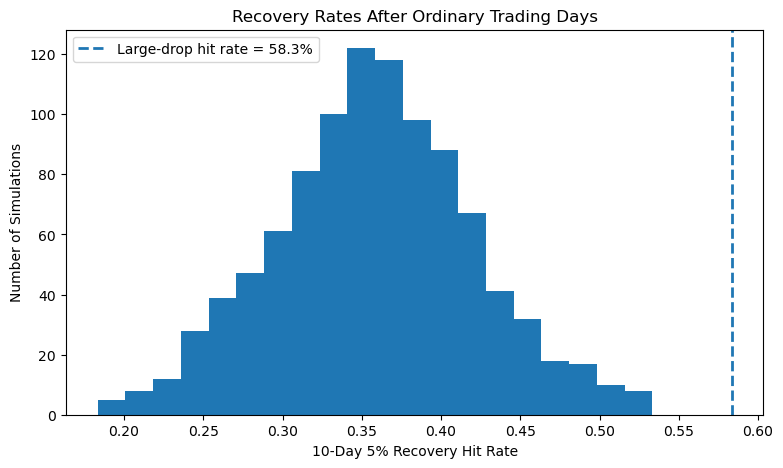

In [21]:
plt.figure(figsize=(9, 5))

# Distribution of recovery hit rates from ordinary-day control samples
plt.hist(
    simulation_hit_rates,
    bins=20
)

# Observed recovery rate following large-drop events
plt.axvline(
    event_hit_rate,
    linestyle="--",
    linewidth=2,
    label=f"Large-drop hit rate = {event_hit_rate:.1%}"
)

plt.xlabel("10-Day 5% Recovery Hit Rate")
plt.ylabel("Number of Simulations")
plt.title("Recovery Rates After Ordinary Trading Days")
plt.legend()

plt.show()

## Preliminary Results

The large-drop event sample produced a **58.3% recovery hit rate**, compared with an average **35.8% hit rate** across 1,000 matched control simulations.

This represents an increase of **22.5 percentage points** relative to the ordinary-day baseline.

The median simulated control hit rate was 35.0%, while 95% of simulated control samples produced hit rates between **25.0% and 48.3%**. The observed large-drop recovery rate of 58.3% therefore lies above the 95% range of outcomes generated by the control simulations.

None of the 1,000 simulated control samples produced a recovery hit rate equal to or greater than the observed 58.3% event hit rate.

These preliminary results support the hypothesis that large single-day declines are associated with a higher probability of reaching a 5% recovery within the following ten trading days than ordinary trading days in this sample.

However, the result should not yet be interpreted as evidence of a profitable trading strategy. The experiment measures whether a recovery threshold is reached, but does not describe the full distribution of subsequent returns, the severity of unsuccessful outcomes, the timing of recoveries, or the effect of realistic entry and exit rules.

### Next Step

The next stage of the analysis will move beyond the binary recovered/not-recovered outcome and compare the **distribution of forward returns following large-drop events with the distribution following ordinary control days**.

This will help determine whether the apparent increase in recovery probability is accompanied by meaningfully different return behaviour, and will allow downside risk, median outcomes and variation between observations to be examined before developing a trading rule.

## Questions Left to Ponder

Q1. Should control observations be sampled from all non-event trading days, or should they also be matched according to market conditions, volatility or time period?

Q2. Some ordinary control days may occur shortly after a large-drop event and therefore form part of the same recovery period. Should these dates be excluded from future control samples?

Q3. How sensitive are the results to the choice of a 5% recovery threshold and a 10-trading-day forward window?

Q4. Does the baseline recovery probability differ substantially between individual stocks?

Q5. Does the magnitude of the initial decline contain information? For example, do -12% declines recover differently from -8% declines?

Q6. Does the result remain visible when a large decline is defined relative to each stock's historical volatility rather than using an absolute -8% threshold?

Q7. How does the distribution of forward returns compare between event and control observations, rather than simply comparing whether a 5% threshold was reached?

Q8. Even if large-drop events show a higher recovery probability than the baseline, would a realistic trading strategy based on these events be profitable after accounting for entry timing, losses and transaction costs?